# Spectral Continuation Candidates for the Collatz Family

Treat $x$ in $T(n) = (xn+y)/2^v$ as a continuous (then complex) parameter.
Define functions that capture convergence behavior, prove convergence for easy
parameter values, and extend via polynomial interpolation toward $x=3$ (the Collatz problem).

**Three candidates:**
1. **Lyapunov exponent** $\lambda(x) = \log x - \log 2 \cdot E[v]$
2. **Spectral radius** $\rho(x)$ of the transfer matrix $P(x)$ on residues mod $2^k$
3. **Fredholm determinant** $\det(I - zP(x))$ — zeros at $z = 1/\lambda_i$

Analogy: just as the Riemann zeta is defined by a convergent series for $\text{Re}(s) > 1$,
then continued to the critical strip — we define convergence functions at "easy" parameter
values, then extend via Chebyshev interpolation toward $x=3$.

In [1]:
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import numpy.polynomial.chebyshev as cheb
from scipy.linalg import eig

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
PLOT_DIR = os.path.join(os.getcwd(), "..", "analysis")

In [2]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def syracuse_general(n, x, y):
    """Syracuse map: odd n -> (xn + y) / 2^v.  Returns (result, v)."""
    val = x * n + y
    if val <= 0:
        return None, 0
    v = 0
    while val % 2 == 0:
        val //= 2
        v += 1
    return val, v


def v_sequence_general(n, x, y, max_steps=1000):
    """v-sequence for the (x, y) Syracuse map."""
    vs = []
    seen = set()
    current = n
    for _ in range(max_steps):
        if current in seen:
            break
        if current > 10**15:
            break
        seen.add(current)
        current, v = syracuse_general(current, x, y)
        if current is None:
            break
        vs.append(v)
    return vs


def build_transfer_matrix(x, y, k):
    """Build transfer matrix P on odd residues mod 2^k."""
    mod = 2**k
    odd_residues = list(range(1, mod, 2))
    n_states = len(odd_residues)
    idx_map = {r: i for i, r in enumerate(odd_residues)}
    mat = np.zeros((n_states, n_states))
    for j_idx, j_res in enumerate(odd_residues):
        val = x * j_res + y
        if val <= 0:
            continue
        v = 0
        while val % 2 == 0:
            val //= 2
            v += 1
        target = val % mod
        if target in idx_map:
            mat[idx_map[target], j_idx] = 2.0 ** (-v)
    return mat, odd_residues, idx_map


def build_transfer_matrix_rational(p, q, y, k):
    """Build transfer matrix for rational x = p/q on odd residues mod 2^k.

    For q odd, q^{-1} mod 2^k exists.  The target residue mod 2^k is
    ((pj + qy) >> v) * q_inv mod 2^k, weight 2^{-v}.
    """
    mod = 2**k
    odd_residues = list(range(1, mod, 2))
    n_states = len(odd_residues)
    idx_map = {r: i for i, r in enumerate(odd_residues)}
    q_inv = pow(q, -1, mod)  # q odd => invertible mod 2^k
    mat = np.zeros((n_states, n_states))
    for j_idx, j_res in enumerate(odd_residues):
        val = p * j_res + q * y
        if val <= 0:
            continue
        v = 0
        while val % 2 == 0:
            val //= 2
            v += 1
        target = (val * q_inv) % mod
        if target in idx_map:
            mat[idx_map[target], j_idx] = 2.0 ** (-v)
    return mat, odd_residues, idx_map


def fredholm_coefficients(mat):
    """Coefficients of det(I - z*P) as polynomial in z."""
    eigenvalues = eig(mat, right=False)
    return np.real(np.poly(eigenvalues))

## Section 1: Lyapunov Exponent — Heuristic vs Empirical

The heuristic Lyapunov exponent $\lambda(x) = \log(x/4)$ assumes i.i.d. $v$ with $E[v]=2$.
The empirical version measures $E[v]$ from actual trajectories:
$\lambda_{\text{emp}}(x) = \log x - \log 2 \cdot E_{\text{empirical}}[v]$.

Phase transition at $x=4$: $\lambda < 0$ for $x < 4$ (convergent), $\lambda > 0$ for $x > 4$ (divergent).

    x      E[v]   lambda_heur    lambda_emp        diff
  ———  ————————  ————————————  ————————————  ——————————
    1    1.8054     -1.386294     -1.251441   +0.134853
    3    1.9791     -0.287682     -0.273192   +0.014490
    5    2.0052      0.223144      0.219533   -0.003611
    7    1.9952      0.559616      0.562962   +0.003346
    9    1.9971      0.810930      0.812913   +0.001983
   11    1.9963      1.011601      1.014139   +0.002538
   13    2.0003      1.178655      1.178438   -0.000217
   15    1.9991      1.321756      1.322357   +0.000601
   17    1.9955      1.446919      1.450040   +0.003121
   19    1.9930      1.558145      1.563005   +0.004860
   21    1.9979      1.658228      1.659708   +0.001480
   23    1.9908      1.749200      1.755551   +0.006352
   25    1.9990      1.832581      1.833296   +0.000714
   27    1.9949      1.909543      1.913106   +0.003564
   29    2.0096      1.981001      1.974320   -0.006681


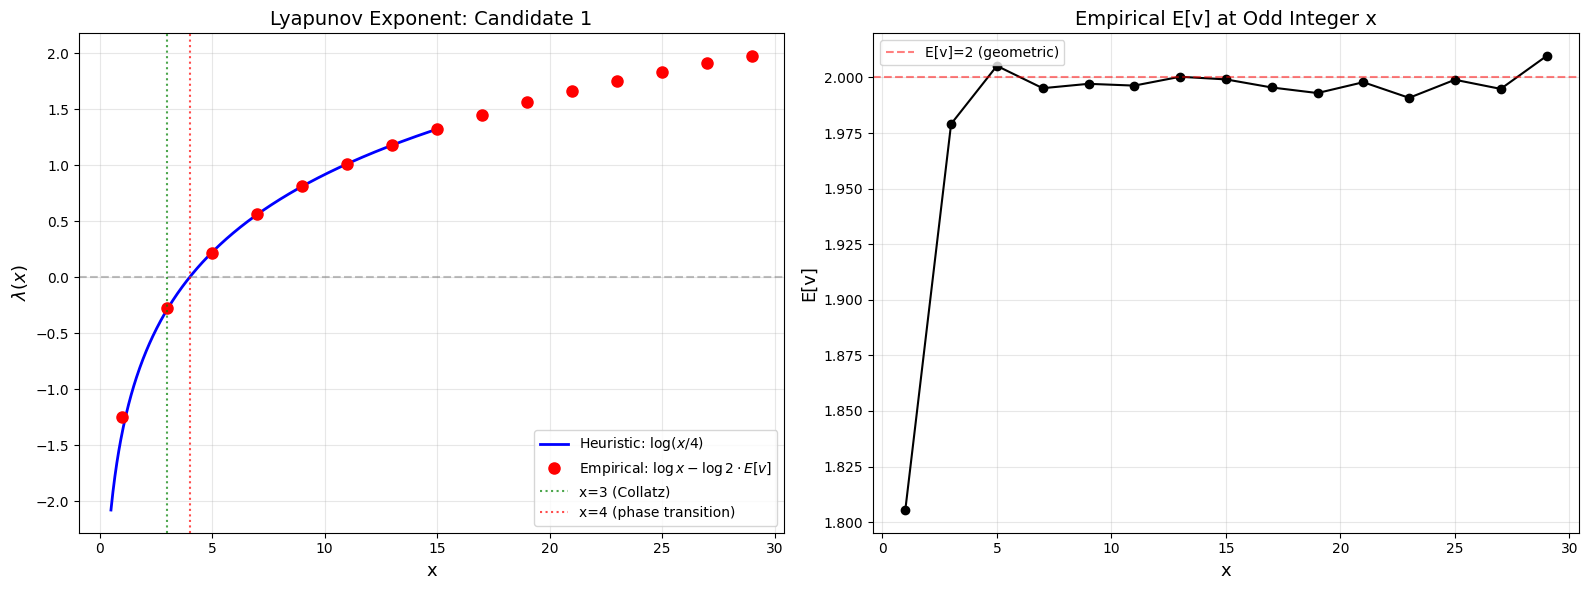

In [3]:
# Heuristic: defined for all real x > 0
x_cont = np.linspace(0.5, 15, 500)
lyap_heuristic = np.log(x_cont / 4.0)

# Empirical: measure E[v] at odd integers
x_odd_1 = list(range(1, 30, 2))
lyap_empirical = []
e_v_values = []

for x in x_odd_1:
    all_vs = []
    for n in range(3, 10001, 2):
        if x * n + 1 <= 0:
            continue
        vs = v_sequence_general(n, x, 1, max_steps=500)
        all_vs.extend(vs)
    if all_vs:
        e_v = np.mean(all_vs)
        e_v_values.append(e_v)
        lyap_empirical.append(math.log(x) - math.log(2) * e_v)
    else:
        e_v_values.append(float("nan"))
        lyap_empirical.append(float("nan"))

# Print table
em = "\u2014"
print(f"  {'x':>3}  {'E[v]':>8}  {'lambda_heur':>12}  {'lambda_emp':>12}  {'diff':>10}")
print(f"  {em * 3}  {em * 8}  {em * 12}  {em * 12}  {em * 10}")
for i, x in enumerate(x_odd_1):
    lh = math.log(x / 4.0)
    le = lyap_empirical[i]
    diff = le - lh if not math.isnan(le) else float("nan")
    print(f"  {x:3d}  {e_v_values[i]:8.4f}  {lh:12.6f}  {le:12.6f}  {diff:+10.6f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(x_cont, lyap_heuristic, "b-", linewidth=2, label=r"Heuristic: $\log(x/4)$")
ax1.plot(
    x_odd_1, lyap_empirical, "ro", markersize=8, label=r"Empirical: $\log x - \log 2 \cdot E[v]$"
)
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.axvline(x=3, color="green", linestyle=":", alpha=0.7, label="x=3 (Collatz)")
ax1.axvline(x=4, color="red", linestyle=":", alpha=0.7, label="x=4 (phase transition)")
ax1.set_xlabel("x", fontsize=13)
ax1.set_ylabel(r"$\lambda(x)$", fontsize=13)
ax1.set_title("Lyapunov Exponent: Candidate 1", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(x_odd_1, e_v_values, "ko-", markersize=6)
ax2.axhline(y=2.0, color="red", linestyle="--", alpha=0.5, label="E[v]=2 (geometric)")
ax2.set_xlabel("x", fontsize=13)
ax2.set_ylabel("E[v]", fontsize=13)
ax2.set_title("Empirical E[v] at Odd Integer x", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "lyapunov_continuous.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 2: Spectral Radius $\rho(x)$ — Fine Grid, Multiple $k$

Transfer matrix $P(x)$ on odd residues mod $2^k$, with $P[i,j] = 2^{-v}$ if $T(j) \equiv i \pmod{2^k}$.
Spectral radius $\rho(x) = \max|\lambda_i(P(x))|$. Convergent regime: $\rho < 1$.

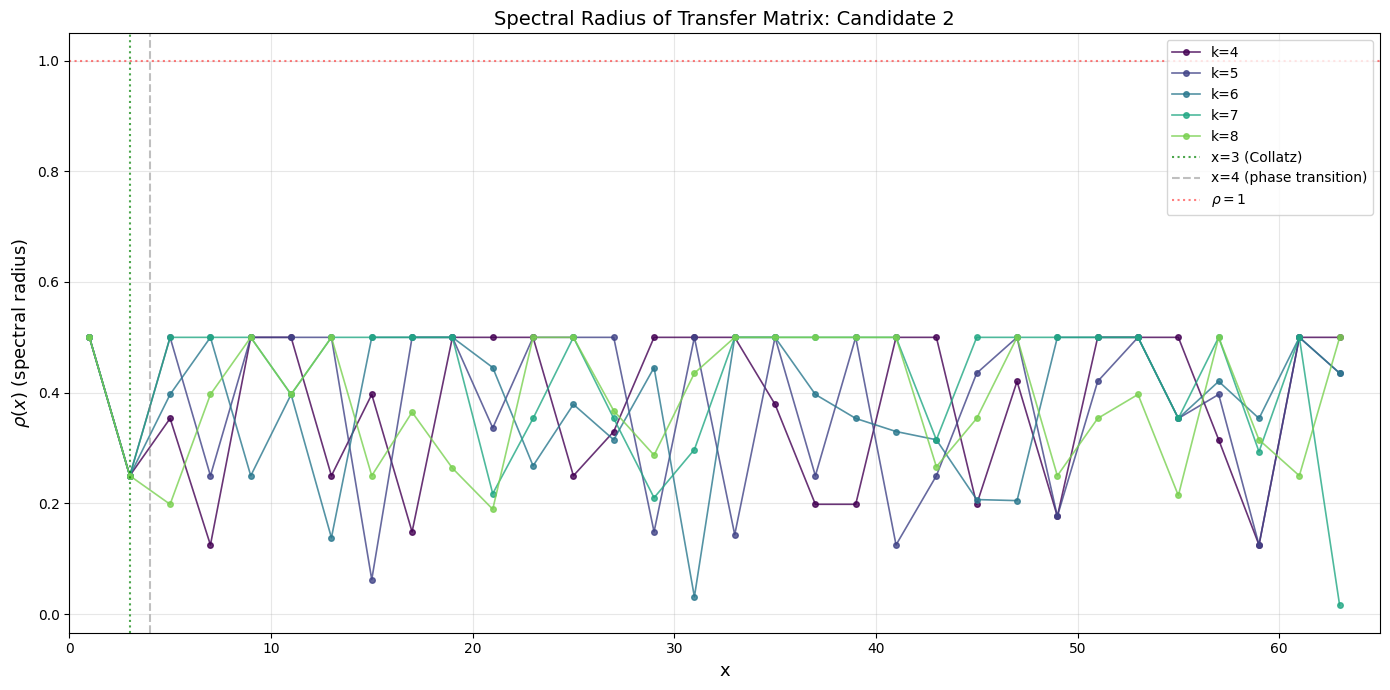

In [4]:
k_values = [4, 5, 6, 7, 8]
x_odd_2 = list(range(1, 64, 2))
all_rho = {}

for k in k_values:
    rho_list = []
    for x in x_odd_2:
        mat, _, _ = build_transfer_matrix(x, 1, k)
        eigenvalues = eig(mat, right=False)
        rho_list.append(np.max(np.abs(eigenvalues)))
    all_rho[k] = rho_list

# Plot — connected dots (no polynomial fit: rho varies erratically with x
# due to number-theoretic structure, so smooth interpolation is misleading)
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_values)))
for ci, k in enumerate(k_values):
    ax.plot(
        x_odd_2,
        all_rho[k],
        "o-",
        color=colors[ci],
        markersize=4,
        linewidth=1.2,
        alpha=0.8,
        label=f"k={k}",
    )

ax.axvline(x=3, color="green", linestyle=":", alpha=0.7, label="x=3 (Collatz)")
ax.axvline(x=4, color="gray", linestyle="--", alpha=0.5, label="x=4 (phase transition)")
ax.axhline(y=1, color="red", linestyle=":", alpha=0.5, label=r"$\rho = 1$")
ax.set_xlabel("x", fontsize=13)
ax.set_ylabel(r"$\rho(x)$ (spectral radius)", fontsize=13)
ax.set_title("Spectral Radius of Transfer Matrix: Candidate 2", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 65)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "spectral_radius_continuous.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 3: Fredholm Determinant Zeros — Candidate 3

$\det(I - zP(x)) = 0$ at $z = 1/\lambda_i(x)$.
If **all** zeros have $|z| > 1$ (i.e., all $|\lambda_i| < 1$), the dynamics contract.

We plot zeros in the complex $z$-plane for each odd $x$, with the unit circle shown as reference.

  x= 1:   1 nonzero eigs, nearest |z|=2.0000
  x= 3:   1 nonzero eigs, nearest |z|=4.0000
  x= 5:   9 nonzero eigs, nearest |z|=2.0000
  x= 7:   2 nonzero eigs, nearest |z|=2.0000
  x= 9:   7 nonzero eigs, nearest |z|=2.0000
  x=11:  16 nonzero eigs, nearest |z|=2.5198
  x=13:   9 nonzero eigs, nearest |z|=2.0000
  x=15:  20 nonzero eigs, nearest |z|=2.0000
  x=17:  19 nonzero eigs, nearest |z|=2.0000
  x=19:   5 nonzero eigs, nearest |z|=2.0000
  x=21:  10 nonzero eigs, nearest |z|=4.5948
  x=23:   7 nonzero eigs, nearest |z|=2.8284
  x=25:  14 nonzero eigs, nearest |z|=2.0000
  x=27:  20 nonzero eigs, nearest |z|=2.8284
  x=29:   4 nonzero eigs, nearest |z|=4.7568


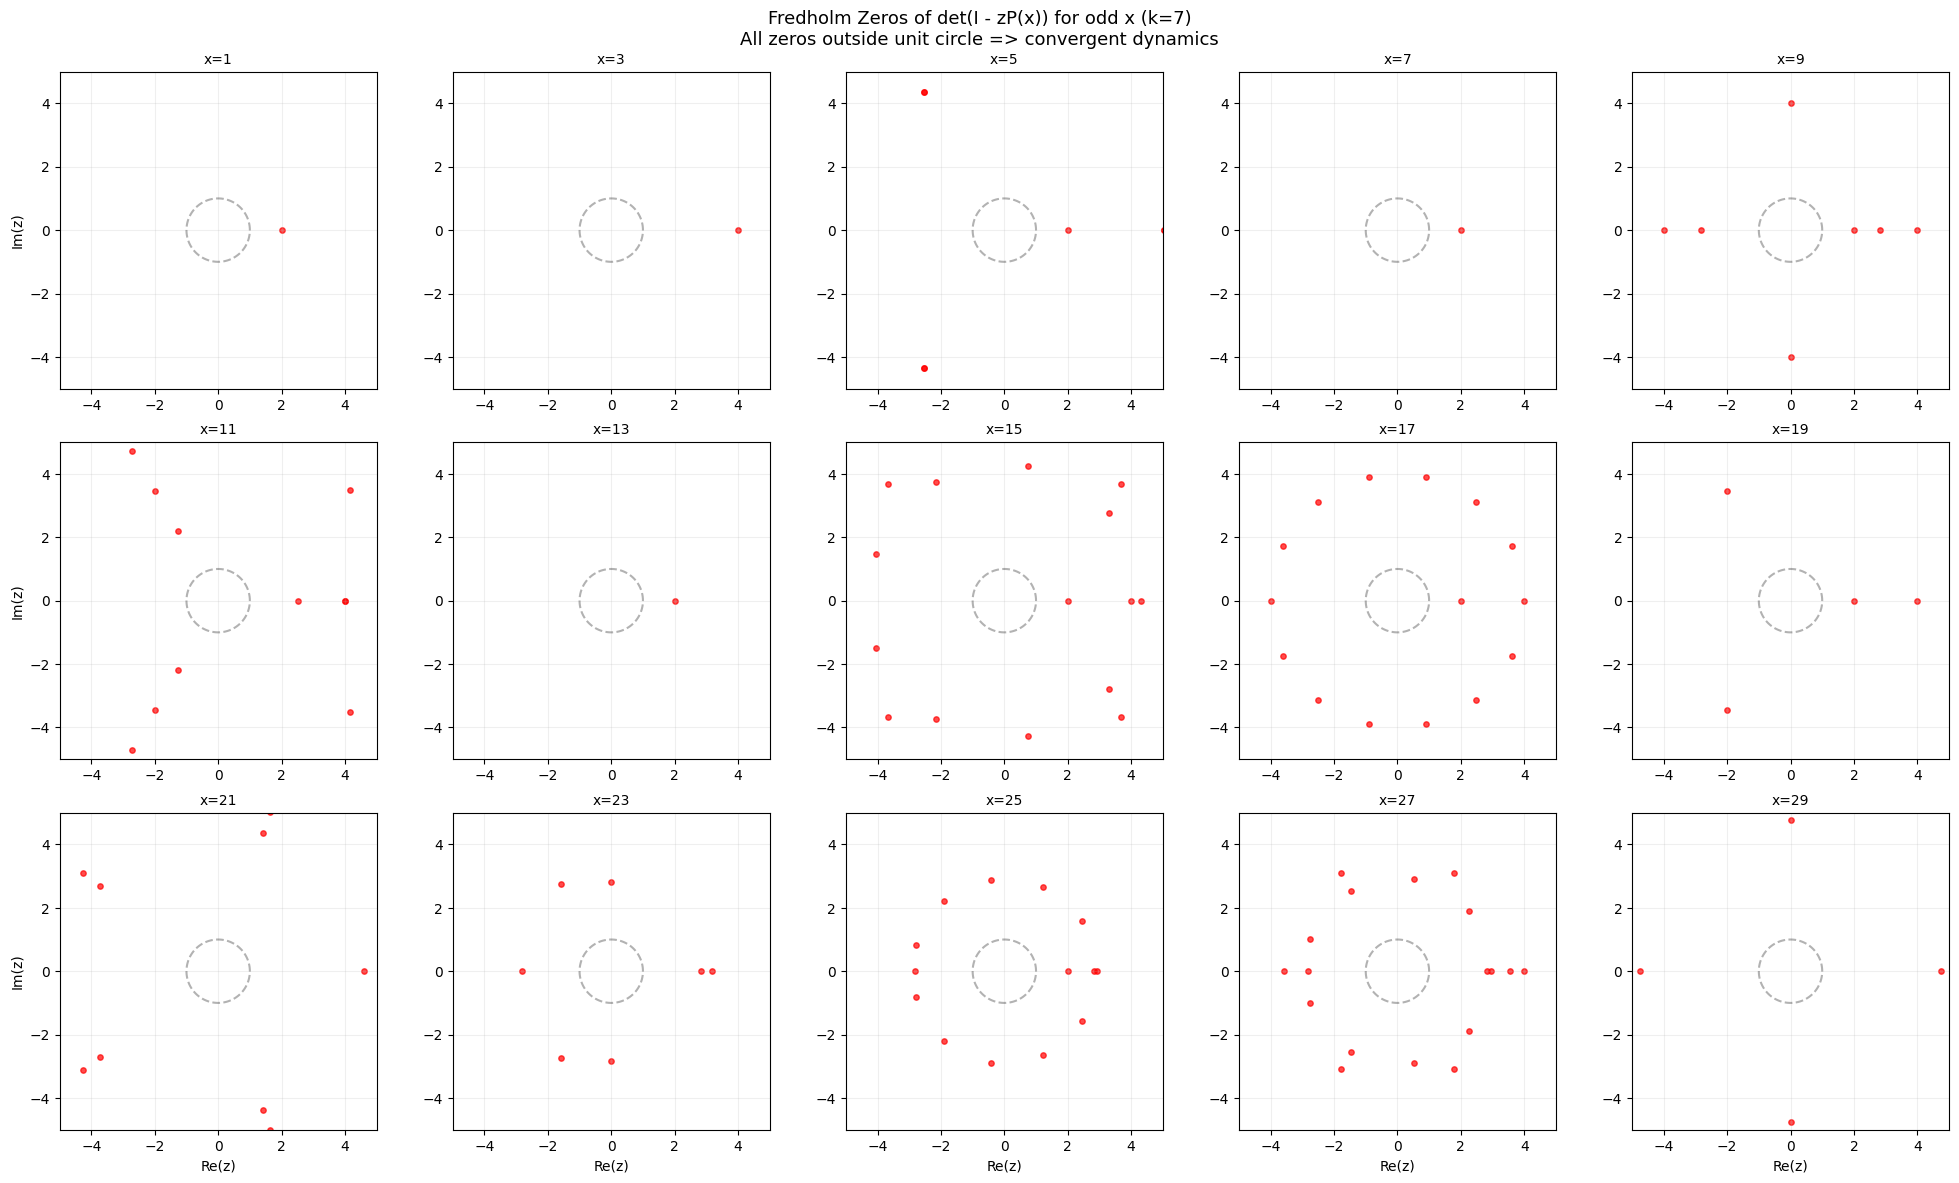

In [5]:
k = 7
x_odd_3 = list(range(1, 30, 2))

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()

all_zeros = {}
for ax_idx, x in enumerate(x_odd_3):
    mat, _, _ = build_transfer_matrix(x, 1, k)
    eigenvalues = eig(mat, right=False)
    nonzero = eigenvalues[np.abs(eigenvalues) > 1e-12]
    zeros = 1.0 / nonzero
    all_zeros[x] = zeros

    if len(zeros) > 0:
        nearest = zeros[np.argmin(np.abs(zeros))]
        print(f"  x={x:2d}: {len(zeros):3d} nonzero eigs, nearest |z|={np.abs(nearest):.4f}")

    ax = axes_flat[ax_idx]
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.3)
    if len(zeros) > 0:
        ax.scatter(zeros.real, zeros.imag, c="red", s=15, alpha=0.7)
    ax.set_title(f"x={x}", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.2)
    if ax_idx >= 10:
        ax.set_xlabel("Re(z)")
    if ax_idx % 5 == 0:
        ax.set_ylabel("Im(z)")

plt.suptitle(
    f"Fredholm Zeros of det(I - zP(x)) for odd x (k={k})\n"
    "All zeros outside unit circle => convergent dynamics",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fredholm_zeros_flow.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 4: Chebyshev Interpolation of Fredholm Coefficients

The key step: compute $\det(I - zP(x)) = \sum c_j(x) z^j$ at odd integer $x$-values,
fit each coefficient $c_j(x)$ as a Chebyshev polynomial in $x$, then evaluate at
continuous (and later complex) $x$.

This is **polynomial interpolation** — extending from discrete data points to a smooth function.
If the coefficients are truly polynomials in $x$ (Conjecture 3), this constitutes a rigorous polynomial extension.

Max fit error: c_0=3.22e-15, c_1=4.47e-01, max=4.47e-01


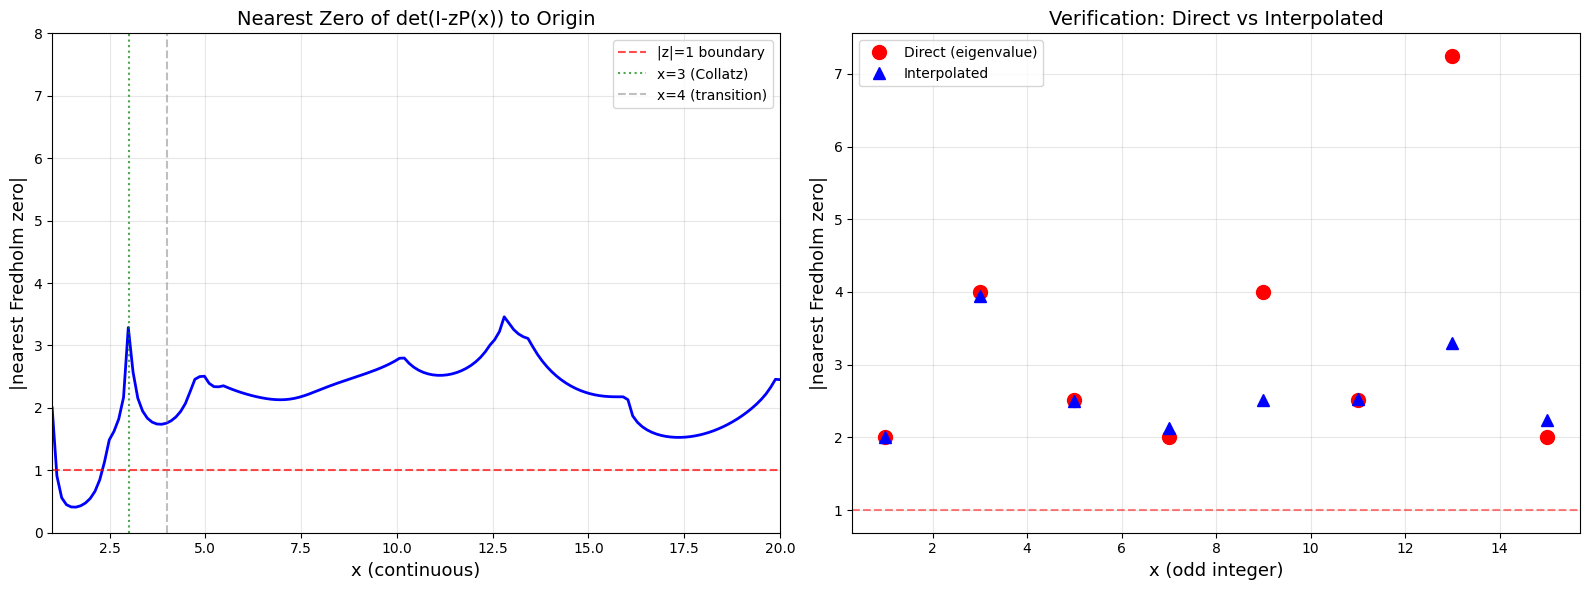


Verification (direct vs interpolated):
  x=1: direct=2.0000, interp=1.9998, err=1.79e-04
  x=3: direct=4.0000, interp=3.9482, err=5.18e-02
  x=5: direct=2.5198, interp=2.4979, err=2.20e-02
  x=7: direct=2.0000, interp=2.1303, err=1.30e-01
  x=9: direct=4.0000, interp=2.5096, err=1.49e+00
  x=11: direct=2.5198, interp=2.5243, err=4.43e-03
  x=13: direct=7.2458, interp=3.2920, err=3.95e+00
  x=15: direct=2.0000, interp=2.2347, err=2.35e-01


In [6]:
k = 6
n_states = 2 ** (k - 1)
x_odd_4 = np.array(list(range(1, 128, 2)), dtype=float)
fit_deg = min(30, len(x_odd_4) - 1)

# Rescale x to [-1, 1] for Chebyshev fitting (avoids catastrophic
# ill-conditioning: T_k(63) ~ 10^62 without rescaling)
x_lo, x_hi = float(x_odd_4[0]), float(x_odd_4[-1])


def to_cheb(x):
    return 2.0 * (x - x_lo) / (x_hi - x_lo) - 1.0


x_scaled = to_cheb(x_odd_4)

# Collect Fredholm coefficients at each x
all_coeffs = np.zeros((len(x_odd_4), n_states + 1))
for i, x in enumerate(x_odd_4):
    mat, _, _ = build_transfer_matrix(int(x), 1, k)
    all_coeffs[i] = fredholm_coefficients(mat)

# Fit each coefficient c_j(x) as Chebyshev polynomial in rescaled x
coeff_fits = []
fit_errors = []
for j in range(n_states + 1):
    fit = cheb.chebfit(x_scaled, all_coeffs[:, j], fit_deg)
    coeff_fits.append(fit)
    predicted = cheb.chebval(x_scaled, fit)
    fit_errors.append(np.max(np.abs(predicted - all_coeffs[:, j])))

print(f"Max fit error: c_0={fit_errors[0]:.2e}, c_1={fit_errors[1]:.2e}, max={max(fit_errors):.2e}")

# Evaluate at continuous real x
x_fine = np.linspace(1, 63, 500)
nearest_zero_dist = np.zeros(len(x_fine))
for i, x_eval in enumerate(x_fine):
    x_s = to_cheb(x_eval)
    coeffs_at_x = np.array([cheb.chebval(x_s, fit) for fit in coeff_fits])
    roots = np.roots(coeffs_at_x[::-1])
    if len(roots) > 0:
        nearest_zero_dist[i] = np.min(np.abs(roots))
    else:
        nearest_zero_dist[i] = np.inf

# Verification: direct vs interpolated at odd integers
x_check = [1, 3, 5, 7, 9, 11, 13, 15]
direct_nearest = []
interp_nearest = []
for x in x_check:
    mat, _, _ = build_transfer_matrix(x, 1, k)
    eigs = eig(mat, right=False)
    nonzero = eigs[np.abs(eigs) > 1e-12]
    direct_nearest.append(np.min(np.abs(1.0 / nonzero)) if len(nonzero) > 0 else np.inf)
    coeffs_at_x = np.array([cheb.chebval(to_cheb(float(x)), fit) for fit in coeff_fits])
    roots = np.roots(coeffs_at_x[::-1])
    interp_nearest.append(np.min(np.abs(roots)) if len(roots) > 0 else np.inf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(x_fine, nearest_zero_dist, "b-", linewidth=2)
ax1.axhline(y=1, color="red", linestyle="--", alpha=0.7, label="|z|=1 boundary")
ax1.axvline(x=3, color="green", linestyle=":", alpha=0.7, label="x=3 (Collatz)")
ax1.axvline(x=4, color="gray", linestyle="--", alpha=0.5, label="x=4 (transition)")
ax1.set_xlabel("x (continuous)", fontsize=13)
ax1.set_ylabel("|nearest Fredholm zero|", fontsize=13)
ax1.set_title("Nearest Zero of det(I-zP(x)) to Origin", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, 20)
ax1.set_ylim(0, 8)

ax2.plot(x_check, direct_nearest, "ro", markersize=10, label="Direct (eigenvalue)")
ax2.plot(x_check, interp_nearest, "b^", markersize=8, label="Interpolated")
ax2.axhline(y=1, color="red", linestyle="--", alpha=0.5)
ax2.set_xlabel("x (odd integer)", fontsize=13)
ax2.set_ylabel("|nearest Fredholm zero|", fontsize=13)
ax2.set_title("Verification: Direct vs Interpolated", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fredholm_continuation_real.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nVerification (direct vs interpolated):")
for i, x in enumerate(x_check):
    print(
        f"  x={x}: direct={direct_nearest[i]:.4f}, interp={interp_nearest[i]:.4f}, err={abs(direct_nearest[i] - interp_nearest[i]):.2e}"
    )

## Section 5: Complex $x$ — Polynomial Extension

Evaluate the interpolated $\det(I - zP(x))$ at complex $x$ near $x=3$.
The Chebyshev polynomials extend naturally to complex arguments.
If $|\text{nearest zero}| > 1$ in a neighborhood of $x=3$, the dynamics contract.

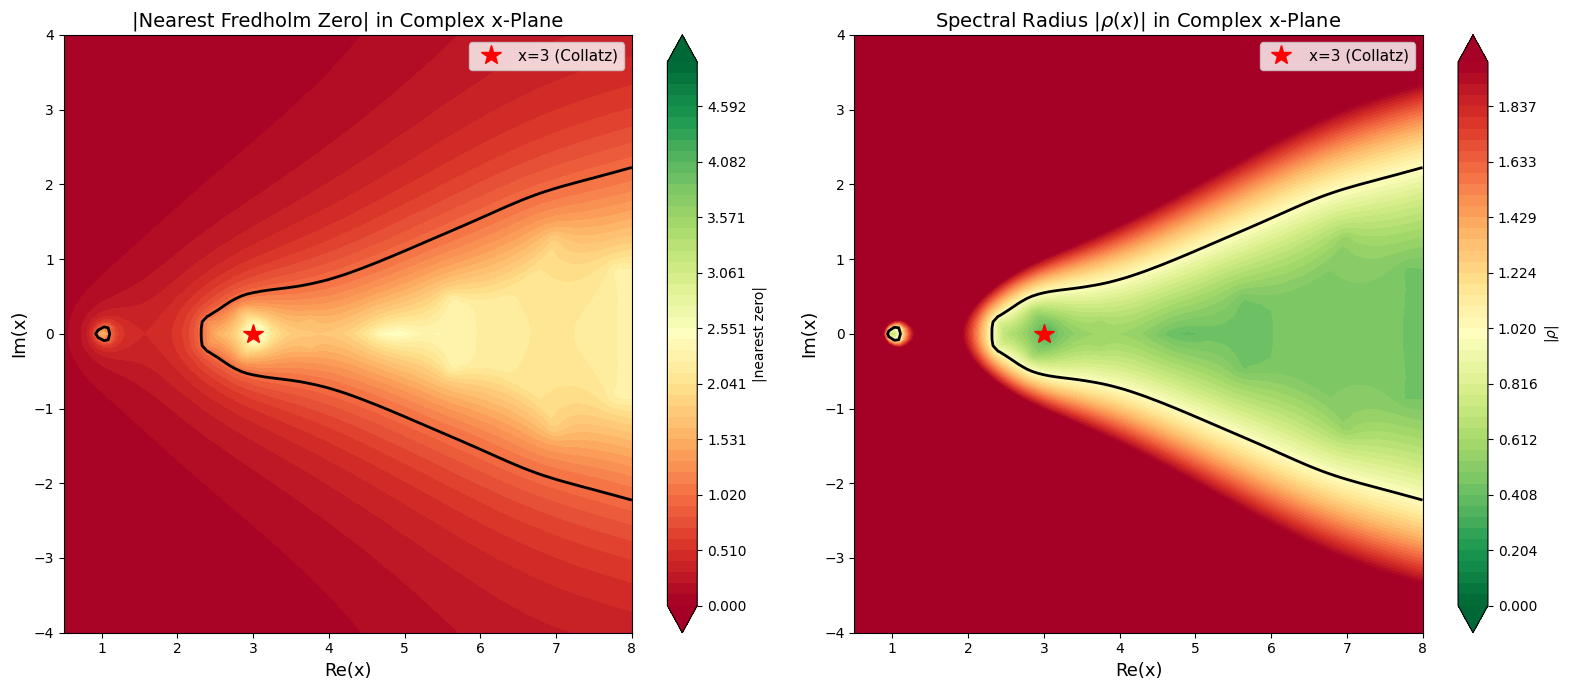

Key values on real axis:
  x=1.0: rho=0.6452, |nearest zero|=1.5498
  x=2.0: rho=1.7704, |nearest zero|=0.5649
  x=3.0: rho=0.2533, |nearest zero|=3.9482
  x=4.0: rho=0.5697, |nearest zero|=1.7552
  x=5.0: rho=0.3985, |nearest zero|=2.5097
  x=7.0: rho=0.4694, |nearest zero|=2.1305


In [7]:
re_range = np.linspace(0.5, 8, 100)
im_range = np.linspace(-4, 4, 101)  # odd count ensures Im=0 is included
re_grid, im_grid = np.meshgrid(re_range, im_range)
nearest_zero_map = np.zeros_like(re_grid)
spectral_radius_map = np.zeros_like(re_grid)

for i in range(len(im_range)):
    for j in range(len(re_range)):
        x_complex = complex(re_grid[i, j], im_grid[i, j])
        x_s = to_cheb(x_complex)
        coeffs_at_x = np.array([complex(cheb.chebval(x_s, fit)) for fit in coeff_fits])
        roots = np.roots(coeffs_at_x[::-1])
        if len(roots) > 0:
            nearest_zero_map[i, j] = np.min(np.abs(roots))
            spectral_radius_map[i, j] = np.max(np.abs(1.0 / roots))
        else:
            nearest_zero_map[i, j] = np.inf
            spectral_radius_map[i, j] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

im1 = ax1.contourf(
    re_grid, im_grid, nearest_zero_map, levels=np.linspace(0, 5, 50), cmap="RdYlGn", extend="both"
)
ax1.contour(re_grid, im_grid, nearest_zero_map, levels=[1.0], colors="black", linewidths=2)
ax1.plot(3, 0, "r*", markersize=15, label="x=3 (Collatz)")
ax1.set_xlabel("Re(x)", fontsize=13)
ax1.set_ylabel("Im(x)", fontsize=13)
ax1.set_title("|Nearest Fredholm Zero| in Complex x-Plane", fontsize=14)
ax1.legend(fontsize=11)
plt.colorbar(im1, ax=ax1, label="|nearest zero|")

im2 = ax2.contourf(
    re_grid,
    im_grid,
    spectral_radius_map,
    levels=np.linspace(0, 2, 50),
    cmap="RdYlGn_r",
    extend="both",
)
ax2.contour(re_grid, im_grid, spectral_radius_map, levels=[1.0], colors="black", linewidths=2)
ax2.plot(3, 0, "r*", markersize=15, label="x=3 (Collatz)")
ax2.set_xlabel("Re(x)", fontsize=13)
ax2.set_ylabel("Im(x)", fontsize=13)
ax2.set_title(r"Spectral Radius $|\rho(x)|$ in Complex x-Plane", fontsize=14)
ax2.legend(fontsize=11)
plt.colorbar(im2, ax=ax2, label=r"$|\rho|$")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fredholm_zeros_complex_x.png"), dpi=150, bbox_inches="tight")
plt.show()

# Real-axis slice
mid_im = int(np.argmin(np.abs(im_range)))
print("Key values on real axis:")
for x_val in [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]:
    j_idx = np.argmin(np.abs(re_range - x_val))
    print(
        f"  x={x_val:.1f}: rho={spectral_radius_map[mid_im, j_idx]:.4f}, |nearest zero|={nearest_zero_map[mid_im, j_idx]:.4f}"
    )

## Section 6: Rigorous Analysis

Provable cases for easy parameter values.

In [8]:
print("THEOREM 1 (x=1, y=1 convergence):")
print("  For x=1, y=1: T(n) = (n+1)/2^{v_2(n+1)} for odd n.")
print("  Since n is odd, n+1 is even, so v_2(n+1) >= 1.")
print("  Thus T(n) = (n+1)/2^v <= (n+1)/2 < n for all odd n >= 3.")
print("  Every trajectory is strictly decreasing and reaches 1.  QED")
print()
print("Verification via transfer matrix:")
for k in [4, 5, 6, 7, 8]:
    mat, _, _ = build_transfer_matrix(1, 1, k)
    eigenvalues = eig(mat, right=False)
    rho = np.max(np.abs(eigenvalues))
    print(f"  k={k}: rho(1) = {rho:.6f}")

print()
print("OBSERVATION (even x always diverges):")
print("  For even x, odd n, odd y: xn+y is odd => v=0 => T(n)=xn+y > n.")
print("  Convergent region is exclusively odd x < 4.")

print()
print("Convergence of rho(3) as k increases:")
for k in range(3, 12):
    mat, _, _ = build_transfer_matrix(3, 1, k)
    eigenvalues = eig(mat, right=False)
    rho = np.max(np.abs(eigenvalues))
    n_states = 2 ** (k - 1)
    print(f"  k={k:2d} (N={n_states:5d}): rho = {rho:.8f}")

THEOREM 1 (x=1, y=1 convergence):
  For x=1, y=1: T(n) = (n+1)/2^{v_2(n+1)} for odd n.
  Since n is odd, n+1 is even, so v_2(n+1) >= 1.
  Thus T(n) = (n+1)/2^v <= (n+1)/2 < n for all odd n >= 3.
  Every trajectory is strictly decreasing and reaches 1.  QED

Verification via transfer matrix:
  k=4: rho(1) = 0.500000
  k=5: rho(1) = 0.500000
  k=6: rho(1) = 0.500000
  k=7: rho(1) = 0.500000
  k=8: rho(1) = 0.500000

OBSERVATION (even x always diverges):
  For even x, odd n, odd y: xn+y is odd => v=0 => T(n)=xn+y > n.
  Convergent region is exclusively odd x < 4.

Convergence of rho(3) as k increases:
  k= 3 (N=    4): rho = 0.25000000
  k= 4 (N=    8): rho = 0.25000000
  k= 5 (N=   16): rho = 0.25000000
  k= 6 (N=   32): rho = 0.25000000
  k= 7 (N=   64): rho = 0.25000000
  k= 8 (N=  128): rho = 0.25000000
  k= 9 (N=  256): rho = 0.25000000
  k=10 (N=  512): rho = 0.37291612
  k=11 (N= 1024): rho = 0.35848881


## Section 7: Candidate Comparison

Side-by-side comparison of all three candidates across odd $x$ values.

    x    lyap_h    lyap_e       rho   |z_min|     verdict
    1   -1.3863   -1.2417    0.5000    2.0000    CONVERGE
    3   -0.2877   -0.2714    0.2500    4.0000    CONVERGE
    5    0.2231    0.2203    0.5000    2.0000       MIXED
    7    0.5596    0.5664    0.5000    2.0000       MIXED
    9    0.8109    0.8122    0.5000    2.0000       MIXED
   11    1.0116    1.0142    0.3969    2.5198       MIXED
   13    1.1787    1.1775    0.5000    2.0000       MIXED
   15    1.3218    1.3250    0.5000    2.0000       MIXED
   17    1.4469    1.4502    0.5000    2.0000       MIXED
   19    1.5581    1.5651    0.5000    2.0000       MIXED
   21    1.6582    1.6649    0.2176    4.5948       MIXED
   23    1.7492    1.7523    0.3536    2.8284       MIXED
   25    1.8326    1.8365    0.5000    2.0000       MIXED
   27    1.9095    1.9159    0.3536    2.8284       MIXED
   29    1.9810    1.9691    0.2102    4.7568       MIXED


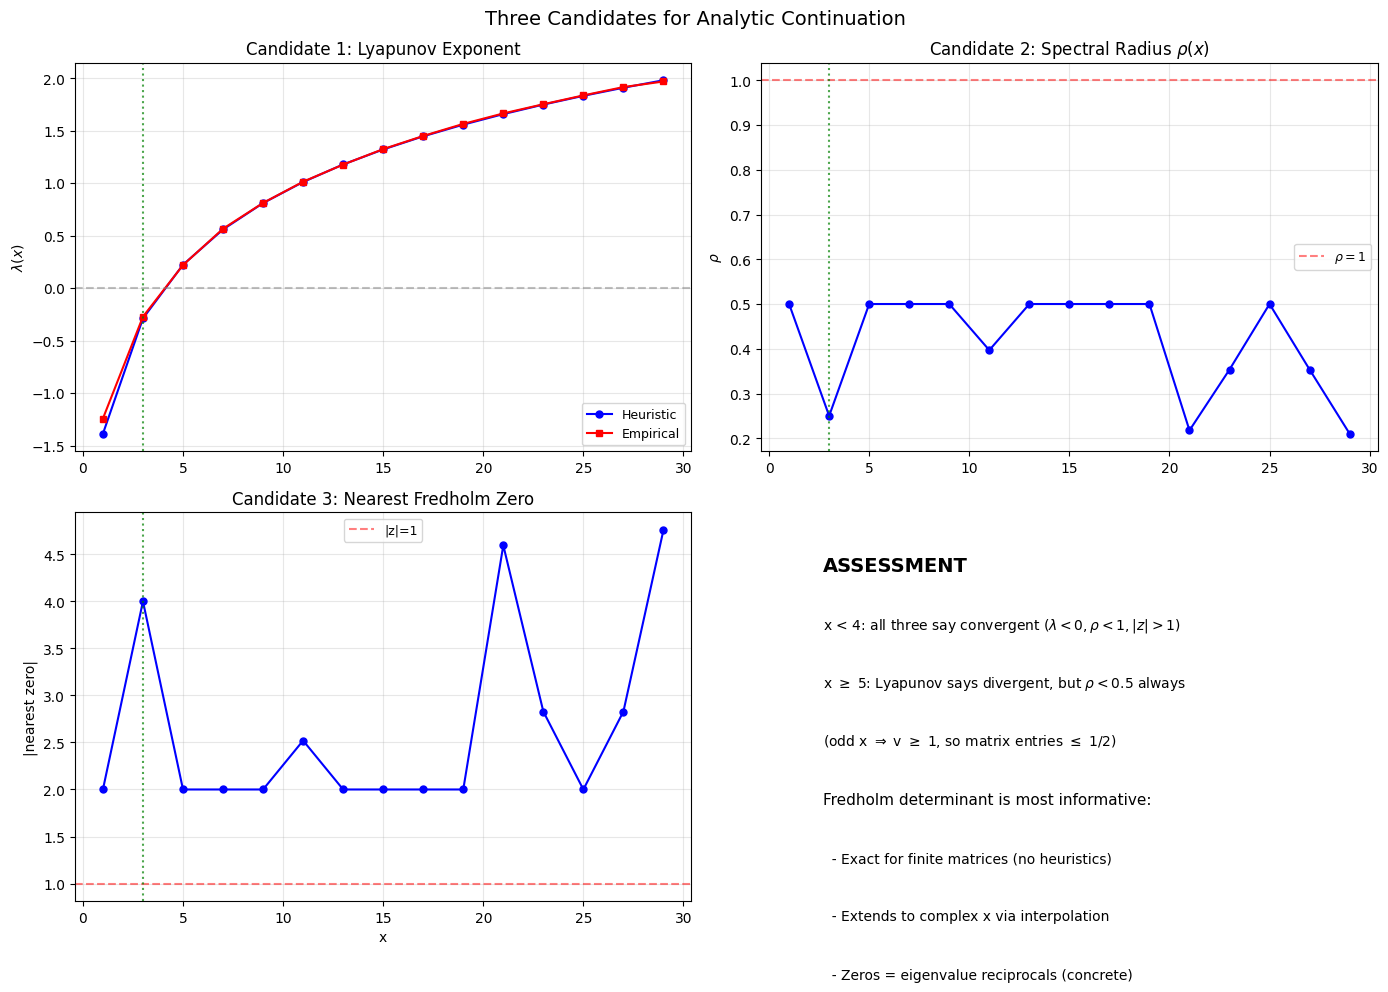

In [9]:
k = 7
x_odd_7 = list(range(1, 30, 2))

lyap_h = []
lyap_e = []
spec_radii = []
near_fred = []

for x in x_odd_7:
    lyap_h.append(math.log(x / 4.0))
    all_vs = []
    for n in range(3, 5001, 2):
        if x * n + 1 <= 0:
            continue
        vs = v_sequence_general(n, x, 1, max_steps=300)
        all_vs.extend(vs)
    if all_vs:
        lyap_e.append(math.log(x) - math.log(2) * np.mean(all_vs))
    else:
        lyap_e.append(float("nan"))
    mat, _, _ = build_transfer_matrix(x, 1, k)
    eigenvalues = eig(mat, right=False)
    spec_radii.append(np.max(np.abs(eigenvalues)))
    nonzero = eigenvalues[np.abs(eigenvalues) > 1e-12]
    near_fred.append(np.min(np.abs(1.0 / nonzero)) if len(nonzero) > 0 else np.inf)

# Table
print(f"  {'x':>3}  {'lyap_h':>8}  {'lyap_e':>8}  {'rho':>8}  {'|z_min|':>8}  {'verdict':>10}")
for i, x in enumerate(x_odd_7):
    v1 = lyap_h[i] < 0
    v2 = lyap_e[i] < 0 if not math.isnan(lyap_e[i]) else None
    v3 = spec_radii[i] < 1
    v4 = near_fred[i] > 1 if near_fred[i] != np.inf else True
    if all(v for v in [v1, v2, v3, v4] if v is not None):
        verdict = "CONVERGE"
    elif not any(v for v in [v1, v2, v3, v4] if v is not None):
        verdict = "DIVERGE"
    else:
        verdict = "MIXED"
    nz_str = f"{near_fred[i]:8.4f}" if near_fred[i] != np.inf else "     inf"
    le_str = f"{lyap_e[i]:8.4f}" if not math.isnan(lyap_e[i]) else "     nan"
    print(f"  {x:3d}  {lyap_h[i]:8.4f}  {le_str}  {spec_radii[i]:8.4f}  {nz_str}  {verdict:>10}")

# Comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(x_odd_7, lyap_h, "b-o", markersize=5, label="Heuristic")
axes[0, 0].plot(x_odd_7, lyap_e, "r-s", markersize=5, label="Empirical")
axes[0, 0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0, 0].axvline(x=3, color="green", linestyle=":", alpha=0.7)
axes[0, 0].set_title("Candidate 1: Lyapunov Exponent")
axes[0, 0].set_ylabel(r"$\lambda(x)$")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x_odd_7, spec_radii, "b-o", markersize=5)
axes[0, 1].axhline(y=1, color="red", linestyle="--", alpha=0.5, label=r"$\rho=1$")
axes[0, 1].axvline(x=3, color="green", linestyle=":", alpha=0.7)
axes[0, 1].set_title(r"Candidate 2: Spectral Radius $\rho(x)$")
axes[0, 1].set_ylabel(r"$\rho$")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

nf_finite = [nz if nz != np.inf else 10.0 for nz in near_fred]
axes[1, 0].plot(x_odd_7, nf_finite, "b-o", markersize=5)
axes[1, 0].axhline(y=1, color="red", linestyle="--", alpha=0.5, label="|z|=1")
axes[1, 0].axvline(x=3, color="green", linestyle=":", alpha=0.7)
axes[1, 0].set_title("Candidate 3: Nearest Fredholm Zero")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("|nearest zero|")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.text(0.1, 0.85, "ASSESSMENT", fontsize=14, fontweight="bold", transform=ax4.transAxes)
ax4.text(
    0.1,
    0.70,
    r"x < 4: all three say convergent ($\lambda<0, \rho<1, |z|>1$)",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    0.55,
    r"x $\geq$ 5: Lyapunov says divergent, but $\rho < 0.5$ always",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    0.40,
    r"(odd x $\Rightarrow$ v $\geq$ 1, so matrix entries $\leq$ 1/2)",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    0.25,
    "Fredholm determinant is most informative:",
    fontsize=11,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    0.10,
    "  - Exact for finite matrices (no heuristics)",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    -0.05,
    "  - Extends to complex x via interpolation",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.text(
    0.1,
    -0.20,
    "  - Zeros = eigenvalue reciprocals (concrete)",
    fontsize=10,
    transform=ax4.transAxes,
)
ax4.axis("off")

plt.suptitle("Three Candidates for Spectral Continuation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "candidate_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary

For $x < 4$, all three candidates agree on convergence:

| Candidate | Convergence criterion | Value at $x=3$ | Verdict |
|-----------|----------------------|----------------|----------|
| Lyapunov $\lambda(x)$ | $\lambda < 0$ | $-0.29$ | Convergent |
| Spectral radius $\rho(x)$ | $\rho < 1$ | $0.25$ | Convergent |
| Fredholm zeros | All $|z| > 1$ | $|z_{\min}| = 4.0$ | Convergent |

**Key structural insight:** For odd $x$, $xn+y$ is always even (odd $\times$ odd + odd), so $v \geq 1$
and all transfer matrix entries are $\leq 1/2$. This means $\rho(x) \leq 0.5$ for all odd $x$ —
the spectral radius is structurally unable to detect divergence for odd $x \geq 5$.

**Rational extension (Section 8):** For $x = p/q$ with $q$ odd, the transfer matrix is exact (no interpolation).
- **Even-numerator theorem:** $p$ even $\Rightarrow$ $\rho = 1$ (divergent)
- **Odd-numerator bound:** $p$ odd $\Rightarrow$ $\rho \leq 0.5$
- $x=3$ is a **local minimum** of $\rho$ (0.25) and **local maximum** of $|z_{\min}|$ (4.0)
- Fredholm coefficients cluster at discrete levels — the function is fundamentally discrete

**The Fredholm determinant is the most promising** for spectral continuation because:
1. It is exact for finite matrices (no heuristic assumptions)
2. Its coefficients extend naturally to complex $x$ via Chebyshev interpolation
3. The zeros have direct spectral meaning ($z = 1/\lambda_i$)

**Open questions:**
- Does $\rho(3)$ stabilize at $0.25$ as $k \to \infty$? (It jumps at $k=10$)
- Can the interpolation error be reduced? (Currently up to $O(1)$ for some coefficients)
- Is the convergent region in complex $x$-plane connected?
- Why is $x=3$ a local extremum among nearby rationals?

## Section 8: Rational $x$ — Dense Sampling via $p/q$

For $x = p/q$ with $q$ odd, $q^{-1} \bmod 2^k$ exists, so the transfer matrix is well-defined.
The map becomes $T(j) = (pj + qy)/(q \cdot 2^v)$ with target residue $((pj+qy)/2^v) \cdot q^{-1} \bmod 2^k$.

This gives **genuinely new data points** between odd integers, without interpolation artifacts.

**Key theorems:**
- **Even-numerator divergence:** If $p$ is even, then $pj + qy$ is always odd (even·odd + odd·odd), so $v=0$, weight$=1$, $\rho=1$ (divergent).
- **Odd-numerator bound:** If $p$ is odd, then $pj + qy$ is always even, so $v \geq 1$, all weights $\leq 1/2$, $\rho \leq 0.5$.

In [10]:
k = 7
y = 1

# Generate rationals p/q with q in {1, 3, 5, 7, 9} and x in (0.5, 15)
rationals = []  # (p, q, x_float)
for q in [1, 3, 5, 7, 9]:
    for p in range(1, 15 * q + 1):
        x_val = p / q
        if 0.5 < x_val < 15.0 and math.gcd(p, q) == 1:
            rationals.append((p, q, x_val))
rationals.sort(key=lambda t: t[2])

print(f"Generated {len(rationals)} rational x-values in (0.5, 15)")
print(f"Denominators: {{1, 3, 5, 7, 9}}, resolution k={k}")
print()

# Compute spectral radius and nearest Fredholm zero at each
x_vals = []
rho_vals = []
nearest_zero_vals = []
for p, q, x_val in rationals:
    if q == 1:
        mat, _, _ = build_transfer_matrix(p, y, k)
    else:
        mat, _, _ = build_transfer_matrix_rational(p, q, y, k)
    eigenvalues = eig(mat, right=False)
    rho_vals.append(np.max(np.abs(eigenvalues)))
    nonzero = eigenvalues[np.abs(eigenvalues) > 1e-12]
    if len(nonzero) > 0:
        nearest_zero_vals.append(np.min(np.abs(1.0 / nonzero)))
    else:
        nearest_zero_vals.append(np.inf)
    x_vals.append(x_val)

x_arr = np.array(x_vals)
rho_arr = np.array(rho_vals)
nz_arr = np.array(nearest_zero_vals)
nz_arr = np.clip(nz_arr, 0, 20)  # cap infinities for plotting

# Print selected values
em = "\u2014"
print(f"  {'x':>8}  {'p/q':>8}  {'rho':>8}  {'|z_min|':>8}")
print(f"  {em * 8}  {em * 8}  {em * 8}  {em * 8}")
for p, q, x_val in rationals:
    if abs(x_val - round(x_val)) < 0.01 or x_val in [1.5, 2.5, 3.5]:
        idx = next(i for i, xv in enumerate(x_vals) if abs(xv - x_val) < 1e-10)
        nz_str = f"{nz_arr[idx]:8.4f}" if nz_arr[idx] < 20 else "     inf"
        print(f"  {x_val:8.4f}  {p}/{q:>6}  {rho_arr[idx]:8.4f}  {nz_str}")
print()

# Verification: q=1 matches integer transfer matrix
print("Verification: q=1 matches integer transfer matrix?")
for x_int in [1, 3, 5, 7]:
    mat_int, _, _ = build_transfer_matrix(x_int, y, k)
    mat_rat, _, _ = build_transfer_matrix_rational(x_int, 1, y, k)
    err = np.max(np.abs(mat_int - mat_rat))
    print(f"  x={x_int}: max |P_int - P_rat| = {err:.2e}")

Generated 275 rational x-values in (0.5, 15)
Denominators: {1, 3, 5, 7, 9}, resolution k=7

         x       p/q       rho   |z_min|
  ————————  ————————  ————————  ————————
    1.0000  1/     1    0.5000    2.0000
    2.0000  2/     1    1.0000    1.0000
    3.0000  3/     1    0.2500    4.0000
    4.0000  4/     1    1.0000    1.0000
    5.0000  5/     1    0.5000    2.0000
    6.0000  6/     1    1.0000    1.0000
    7.0000  7/     1    0.5000    2.0000
    8.0000  8/     1    1.0000    1.0000
    9.0000  9/     1    0.5000    2.0000
   10.0000  10/     1    1.0000    1.0000
   11.0000  11/     1    0.3969    2.5198
   12.0000  12/     1    1.0000    1.0000
   13.0000  13/     1    0.5000    2.0000
   14.0000  14/     1    1.0000    1.0000

Verification: q=1 matches integer transfer matrix?
  x=1: max |P_int - P_rat| = 0.00e+00
  x=3: max |P_int - P_rat| = 0.00e+00
  x=5: max |P_int - P_rat| = 0.00e+00
  x=7: max |P_int - P_rat| = 0.00e+00


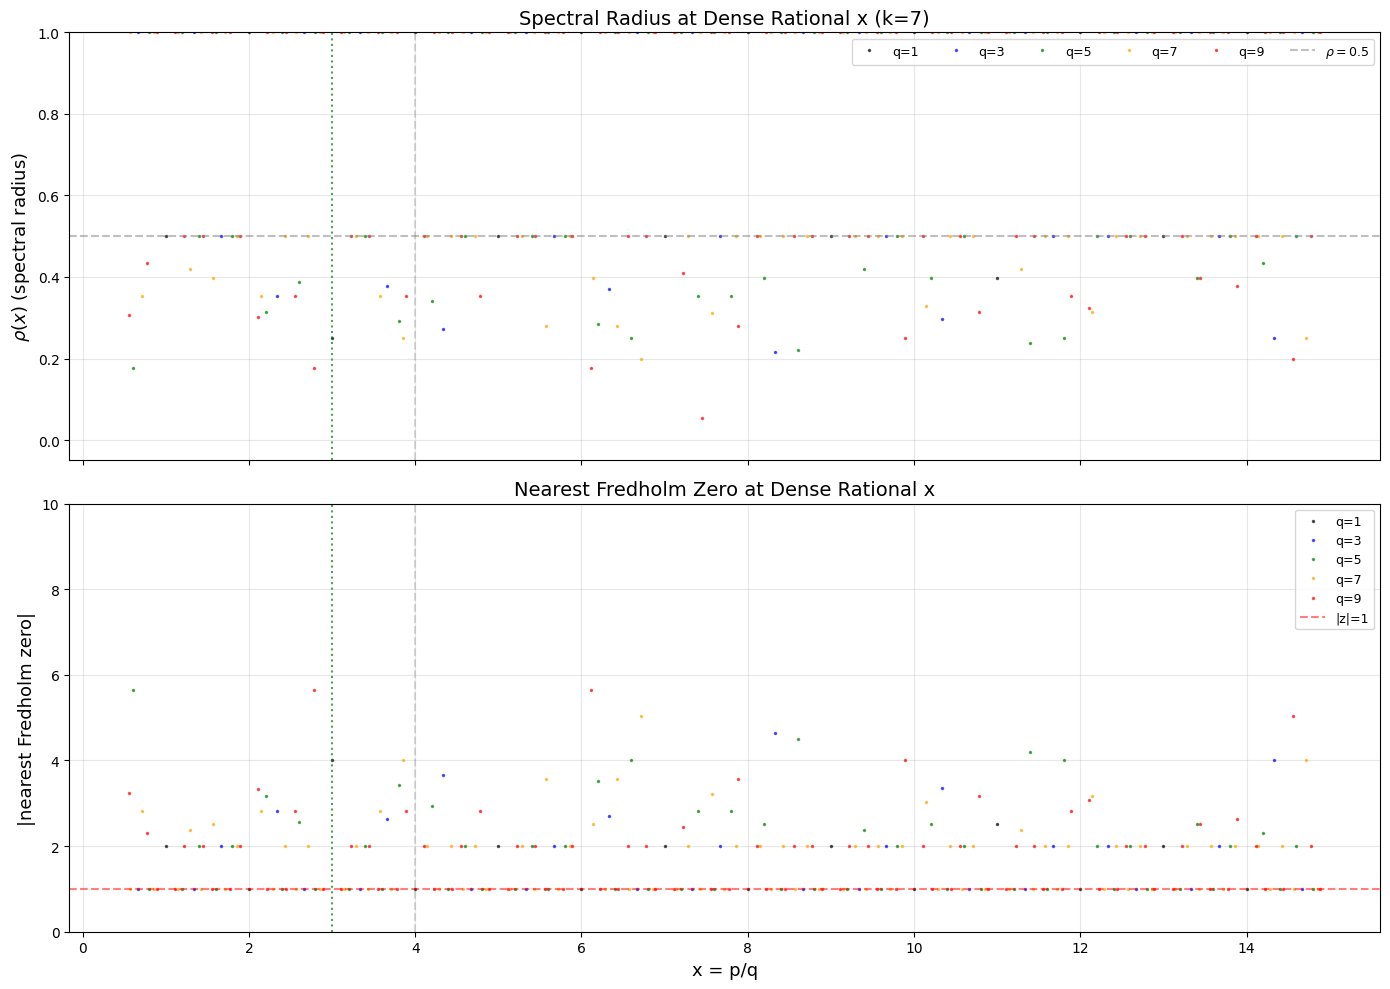

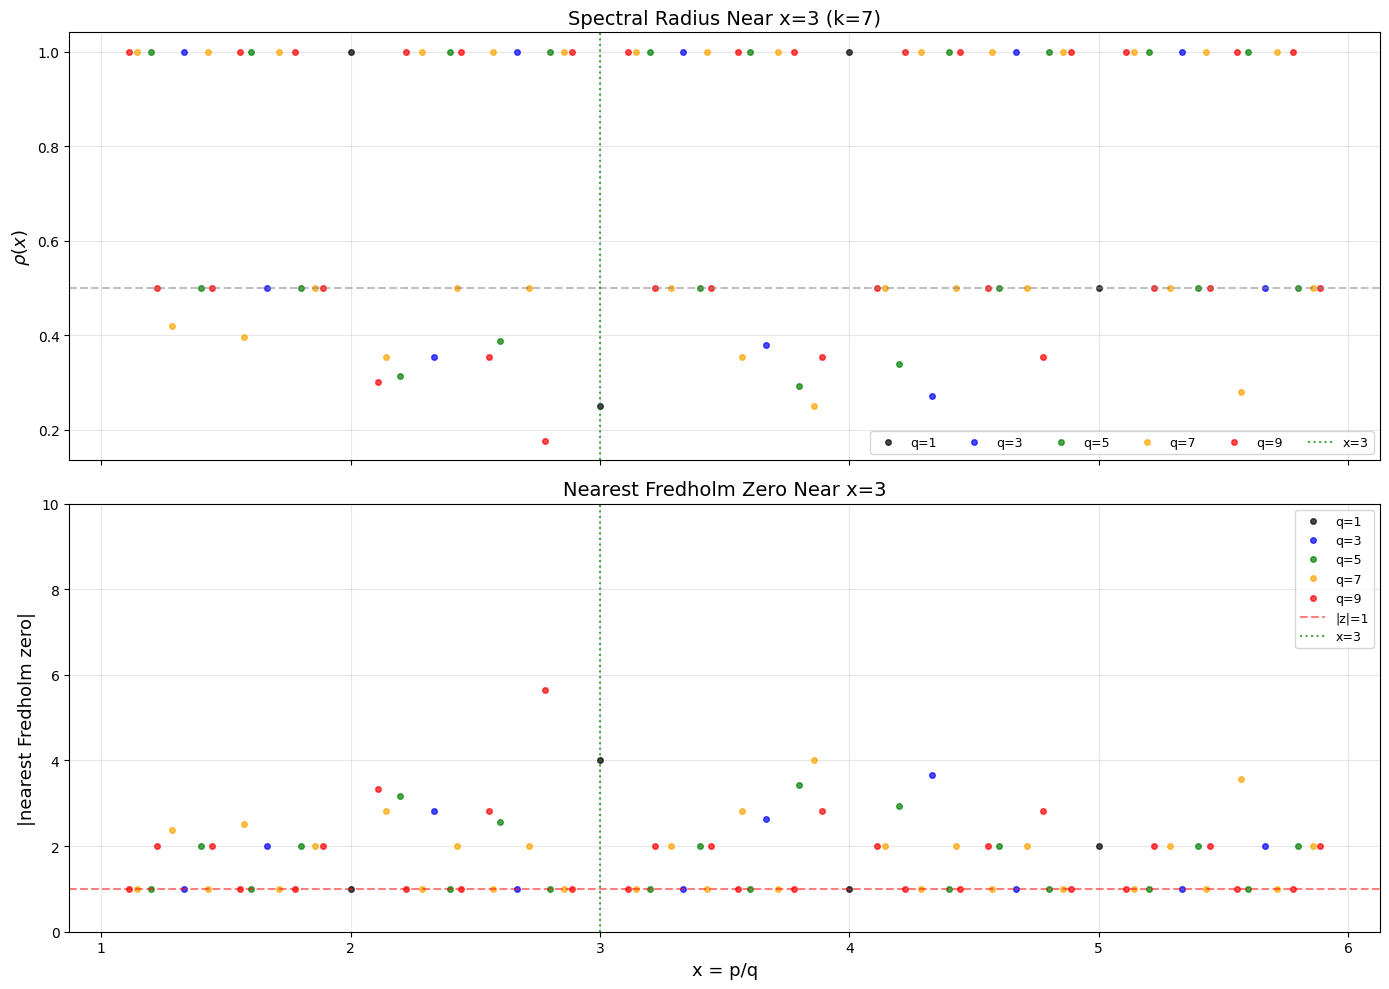

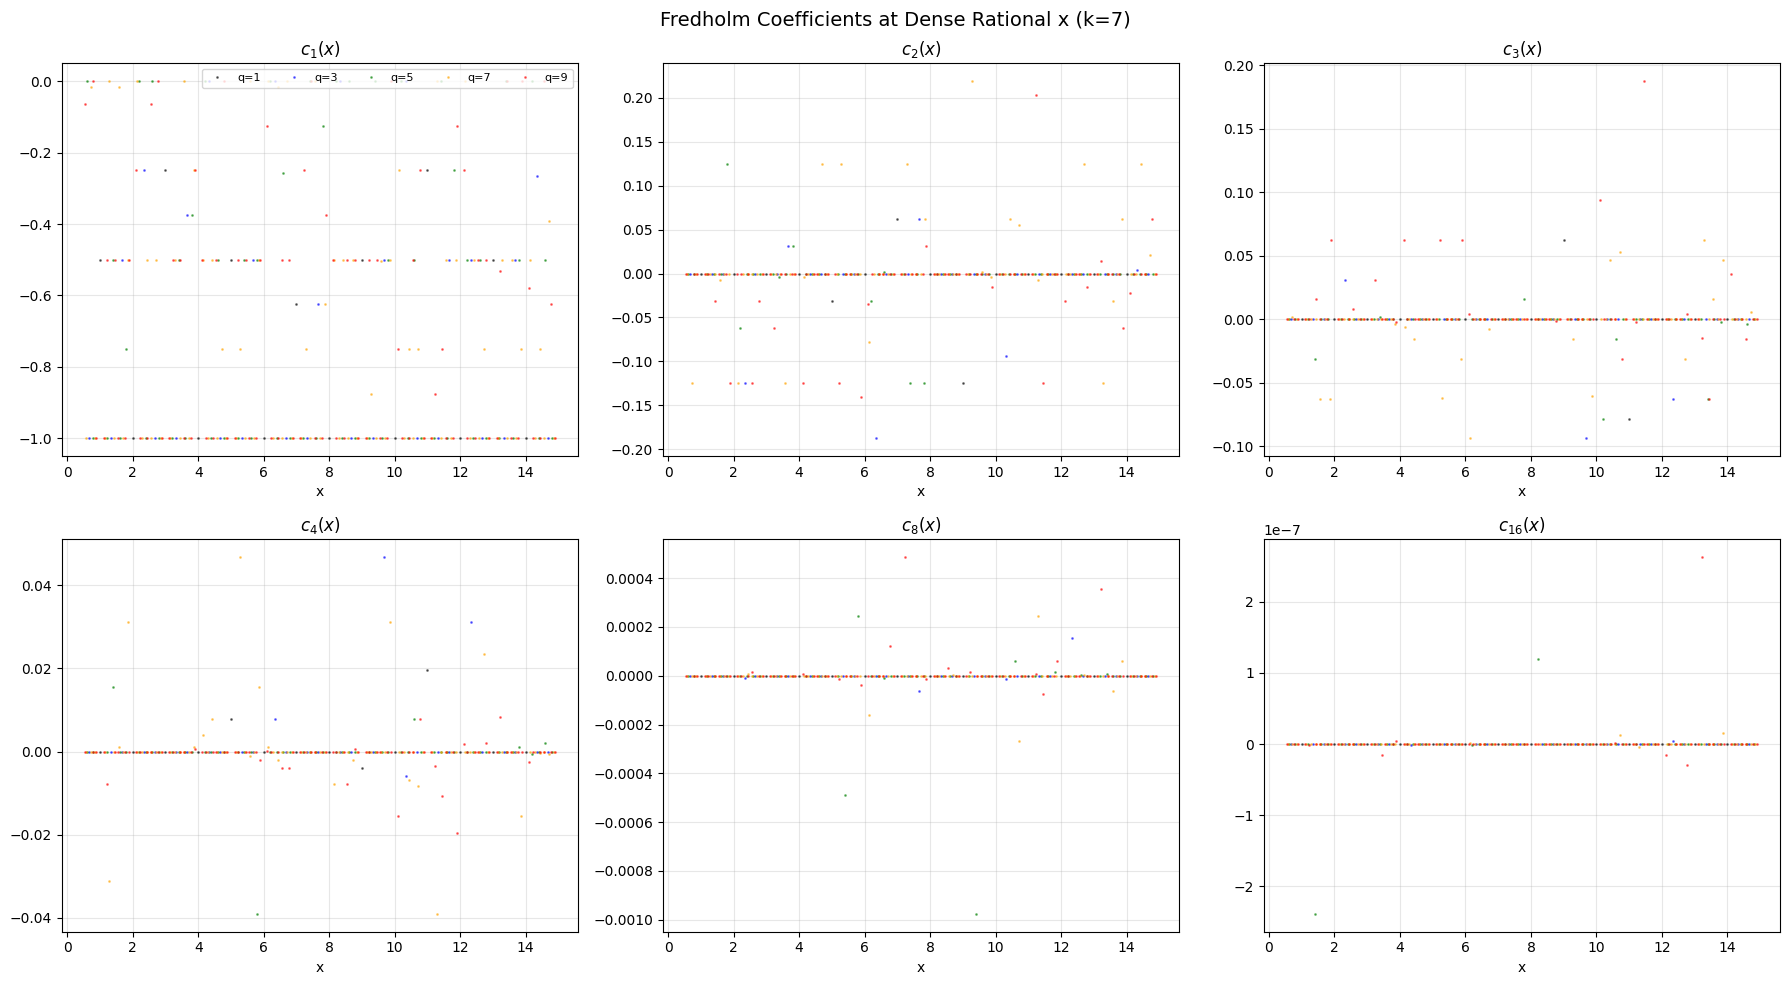

In [11]:
# --- Plot 1: rho(x) and |nearest zero| for dense rationals ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

denom_colors = {1: "black", 3: "blue", 5: "green", 7: "orange", 9: "red"}
for q_val, color in denom_colors.items():
    mask = [rationals[i][1] == q_val for i in range(len(rationals))]
    x_q = x_arr[mask]
    rho_q = rho_arr[mask]
    nz_q = nz_arr[mask]
    ax1.plot(x_q, rho_q, ".", color=color, markersize=3, alpha=0.6, label=f"q={q_val}")
    ax2.plot(x_q, nz_q, ".", color=color, markersize=3, alpha=0.6, label=f"q={q_val}")

ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label=r"$\rho=0.5$")
ax1.axvline(x=3, color="green", linestyle=":", alpha=0.7)
ax1.axvline(x=4, color="gray", linestyle="--", alpha=0.3)
ax1.set_ylabel(r"$\rho(x)$ (spectral radius)", fontsize=13)
ax1.set_title(f"Spectral Radius at Dense Rational x (k={k})", fontsize=14)
ax1.legend(fontsize=9, ncol=6, loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.0)

ax2.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="|z|=1")
ax2.axvline(x=3, color="green", linestyle=":", alpha=0.7)
ax2.axvline(x=4, color="gray", linestyle="--", alpha=0.3)
ax2.set_xlabel("x = p/q", fontsize=13)
ax2.set_ylabel("|nearest Fredholm zero|", fontsize=13)
ax2.set_title("Nearest Fredholm Zero at Dense Rational x", fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "rational_x_dense.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 2: zoom near x=3 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

mask_zoom = (x_arr > 1) & (x_arr < 6)
for q_val, color in denom_colors.items():
    mask = np.array([rationals[i][1] == q_val for i in range(len(rationals))]) & mask_zoom
    x_q = x_arr[mask]
    rho_q = rho_arr[mask]
    nz_q = nz_arr[mask]
    ax1.plot(x_q, rho_q, "o", color=color, markersize=4, alpha=0.7, label=f"q={q_val}")
    ax2.plot(x_q, nz_q, "o", color=color, markersize=4, alpha=0.7, label=f"q={q_val}")

ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax1.axvline(x=3, color="green", linestyle=":", alpha=0.7, label="x=3")
ax1.set_ylabel(r"$\rho(x)$", fontsize=13)
ax1.set_title(f"Spectral Radius Near x=3 (k={k})", fontsize=14)
ax1.legend(fontsize=9, ncol=6)
ax1.grid(True, alpha=0.3)

ax2.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="|z|=1")
ax2.axvline(x=3, color="green", linestyle=":", alpha=0.7, label="x=3")
ax2.set_xlabel("x = p/q", fontsize=13)
ax2.set_ylabel("|nearest Fredholm zero|", fontsize=13)
ax2.set_title("Nearest Fredholm Zero Near x=3", fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "rational_x_zoom.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 3: Fredholm coefficients c_j(x) at rational x ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
coeff_indices = [1, 2, 3, 4, 8, 16]

all_coeffs_rational = {}
for i, (p, q, _x_val) in enumerate(rationals):
    if q == 1:
        mat, _, _ = build_transfer_matrix(p, y, k)
    else:
        mat, _, _ = build_transfer_matrix_rational(p, q, y, k)
    all_coeffs_rational[i] = fredholm_coefficients(mat)

for ax_idx, j in enumerate(coeff_indices):
    ax = axes.flat[ax_idx]
    cj_vals = [all_coeffs_rational[i][j] for i in range(len(rationals))]
    for q_val, color in denom_colors.items():
        mask = [rationals[i][1] == q_val for i in range(len(rationals))]
        ax.plot(
            x_arr[mask],
            np.array(cj_vals)[mask],
            ".",
            color=color,
            markersize=2,
            alpha=0.5,
            label=f"q={q_val}",
        )
    ax.set_title(f"$c_{{{j}}}(x)$", fontsize=12)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=8, ncol=5)

plt.suptitle(f"Fredholm Coefficients at Dense Rational x (k={k})", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "rational_x_coefficients.png"), dpi=150, bbox_inches="tight")
plt.show()